## Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras._tf_keras.keras import layers
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from keras._tf_keras.keras.losses import SparseCategoricalCrossentropy
from keras._tf_keras.keras.callbacks import EarlyStopping

## Set Constant Values

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
CHANNELS = 3

## Download or load the dataset 

In [3]:
training = "Data/Lungs/train/"
testing = "Data/Lungs/test/"

## Image Preprocessing

### Create Dataset for train,test,validation

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 3559 files belonging to 5 classes.
Using 2848 files for training.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
  testing,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 893 files belonging to 5 classes.
Using 715 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 3559 files belonging to 5 classes.
Using 711 files for validation.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['Covid', 'Normal', 'Pneumonia', 'Pneumothorax', 'Tuberculosis']


## Visualize the data

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


## Configure the dataset for performance

In [9]:
trian_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Standardize the data

In [10]:
normalization_layer = layers.Rescaling(1./255)

In [11]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.98823535


## Resize and Rescale

In [12]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(0.1 / 256)
])

## Data Augmentation

In [13]:
data_augmentation  = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

In [14]:
train_ds = train_ds.map(
    lambda x,y: (data_augmentation(x, training=True),y),
).prefetch(buffer_size = tf.data.AUTOTUNE)

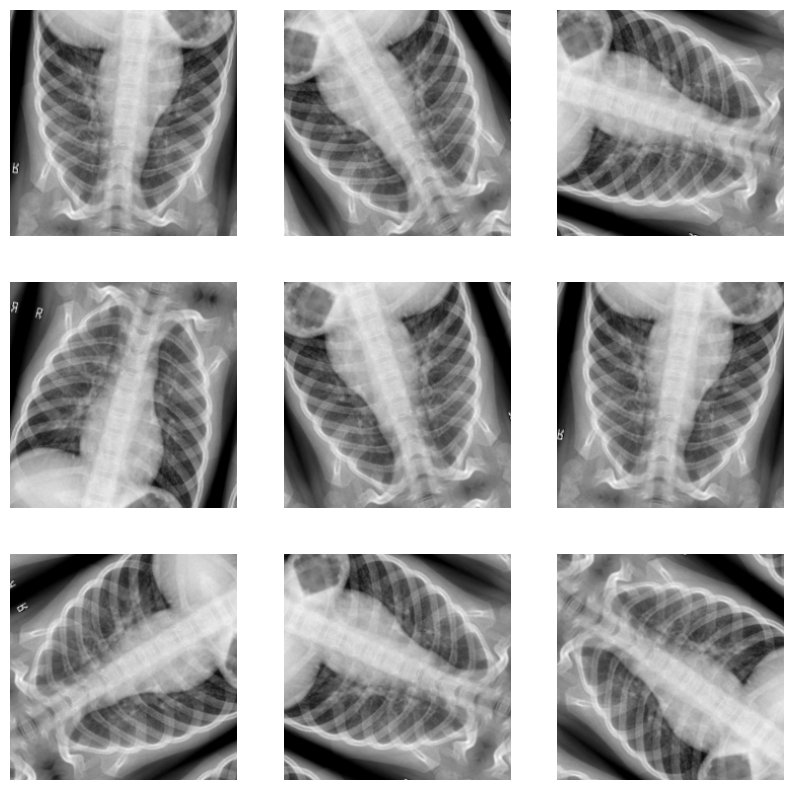

In [15]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Define the EarlyStopping callback

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # or 'val_accuracy' depending on your goal
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# VGG19 Model Implementation

Import the base model

In [17]:
from keras._tf_keras.keras.applications.vgg19 import VGG19

Create a base model

In [18]:
conv_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
)
conv_base.trainable = False

Add Connected layers to VGG19 Base

In [19]:
model_vgg = Sequential()
resize_and_rescale
model_vgg.add(conv_base)
model_vgg.add(Flatten())
model_vgg.add(Dense(256,activation='relu'))
model_vgg.add(Dropout(0.5))
model_vgg.add(BatchNormalization())
model_vgg.add(Dense(num_classes,activation='sigmoid'))
model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,449,477 (100.90 MB)

 Trainable params: 6,424,581 (24.51 MB)

 Non-trainable params: 20,024,896 (76.39 MB)

Compile the model

In [20]:
model_vgg.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the model

In [21]:
epochs = 5
history = model_vgg.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1055s 12s/step - accuracy: 0.6402 - loss: 0.9644 - val_accuracy: 0.7778 - val_loss: 0.6006
Epoch 2/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1049s 12s/step - accuracy: 0.7886 - loss: 0.5085 - val_accuracy: 0.7736 - val_loss: 0.5995
Epoch 3/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1042s 12s/step - accuracy: 0.8166 - loss: 0.4649 - val_accuracy: 0.8073 - val_loss: 0.4761
Epoch 4/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1049s 12s/step - accuracy: 0.8162 - loss: 0.4416 - val_accuracy: 0.8368 - val_loss: 0.4057
Epoch 5/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1240s 14s/step - accuracy: 0.8363 - loss: 0.4076 - val_accuracy: 0.8031 - val_loss: 0.4550
Restoring model weights from the end of the best epoch: 4.


### Evaluate the model

In [22]:
model_vgg.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 262s 11s/step - accuracy: 0.8332 - loss: 0.4404


[0.44567930698394775, 0.8279720544815063]

# Visualize training results

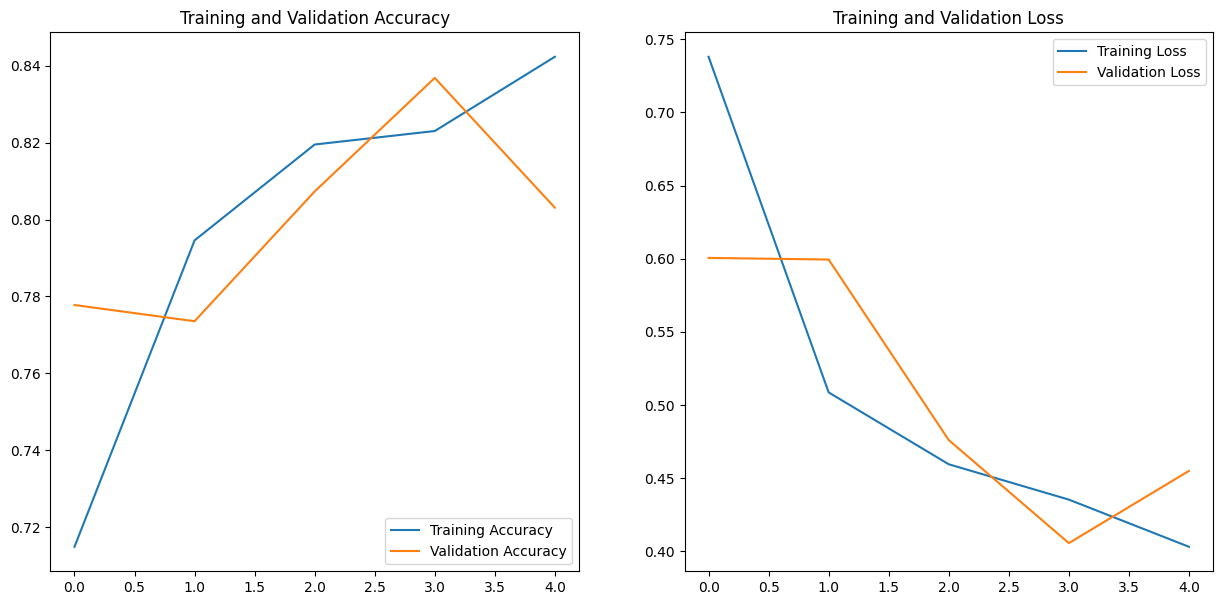

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Save the model

In [24]:
model_vgg.save("Model VGG19.keras")

# DenseNet Model Implementation

In [25]:
from keras._tf_keras.keras.applications import DenseNet121
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [26]:
model_dense = Sequential()
resize_and_rescale
model_dense.add(base_model)
model_dense.add(Flatten())
model_dense.add(Dense(256,activation='relu'))
model_dense.add(Dropout(0.5))
model_dense.add(BatchNormalization())
model_dense.add(Dense(num_classes,activation='sigmoid'))
model_dense.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,885,125 (75.86 MB)

 Trainable params: 12,847,109 (49.01 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [27]:
model_dense.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [37]:
epochs = 5
history = model_dense.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.6896 - loss: 0.7715 - val_accuracy: 0.7089 - val_loss: 0.6851
Epoch 2/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step - accuracy: 0.7431 - loss: 0.6573 - val_accuracy: 0.7567 - val_loss: 0.6071
Epoch 3/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.7679 - loss: 0.6012 - val_accuracy: 0.7229 - val_loss: 0.6255
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Evaluate the model

In [24]:
model_dense.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6693 - loss: 0.6207


[0.6391549110412598, 0.6538461446762085]

Visualize training accuracy and loss

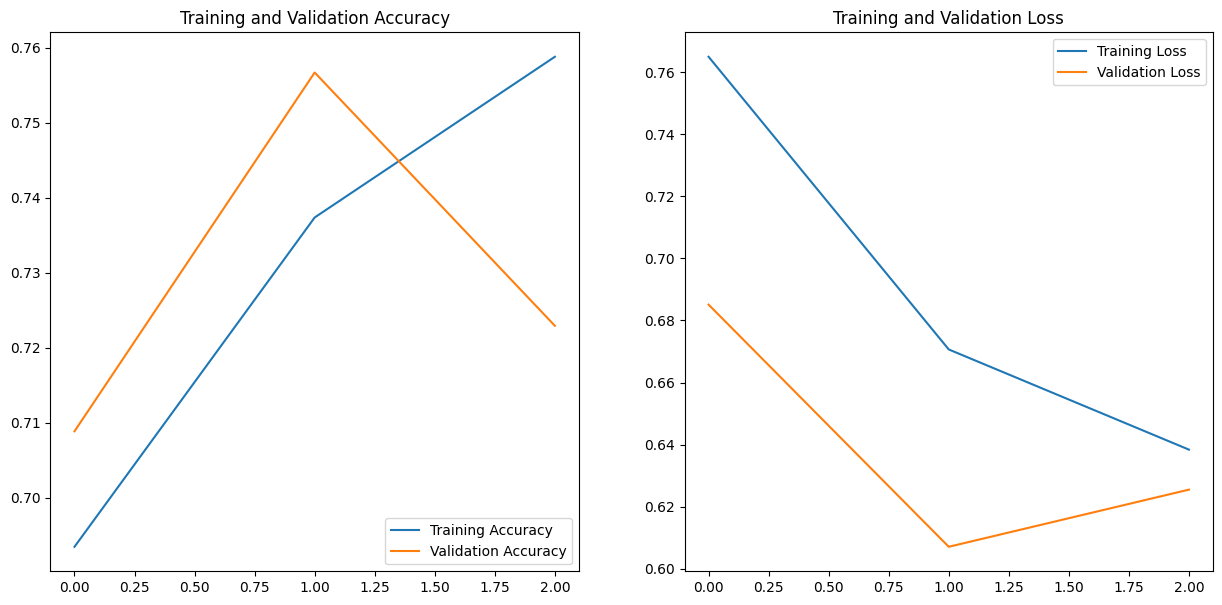

In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [40]:
model_dense.save('Model DenseNet.keras')

# EfficientNet Model Implementation

In [29]:
from keras._tf_keras.keras.applications.efficientnet_v2 import EfficientNetV2B0
base_eff = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_eff.trainable = False

In [30]:
model_eff = Sequential()
resize_and_rescale
model_eff.add(base_eff)
model_eff.add(Flatten())
model_eff.add(Dense(256,activation='relu'))
model_eff.add(Dropout(0.5))
model_eff.add(BatchNormalization())
model_eff.add(Dense(num_classes,activation='sigmoid'))
model_eff.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,978,197 (83.84 MB)

 Trainable params: 16,058,373 (61.26 MB)

 Non-trainable params: 5,919,824 (22.58 MB)

In [31]:
model_eff.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [32]:
epochs = 10
history = model_eff.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6222 - loss: 1.0132 - val_accuracy: 0.7651 - val_loss: 0.6337
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8092 - loss: 0.4936 - val_accuracy: 0.8186 - val_loss: 0.4096
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8136 - loss: 0.4609 - val_accuracy: 0.7848 - val_loss: 0.5008
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Evaluate the model

In [33]:
model_eff.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 707ms/step - accuracy: 0.7783 - loss: 0.5633


[0.5946236848831177, 0.7762237787246704]

# Visualize training accuracy and losses

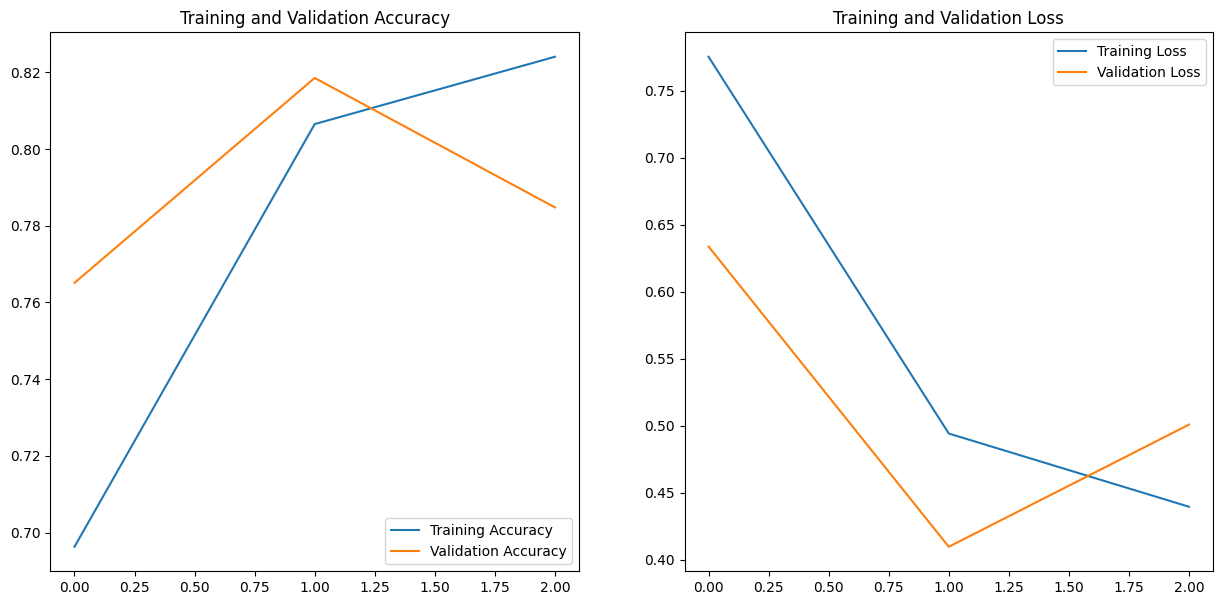

In [35]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [36]:
model_eff.save('Model EfficientNet.keras')